<a href="https://colab.research.google.com/github/ByungChul-Cha/Deep_Learning_Study/blob/main/Day03/%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1_%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **04-01. Logistic Regression(로지스틱 회귀)**

# Binary Classification(이진 분류)
- 정의: 둘 중 하나를 결정하는 문제 (0 또는 1)
- H(x) = Wx + b(선형 회귀) -> H(x) = f(Wx + b)

# Sigmoid function(시그모이드 함수)
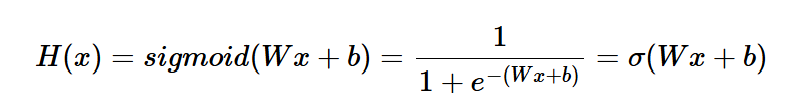

In [ ]:
# 실행한 브라우저에서 바로 그림을 볼 수 있게 해주는 역할
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

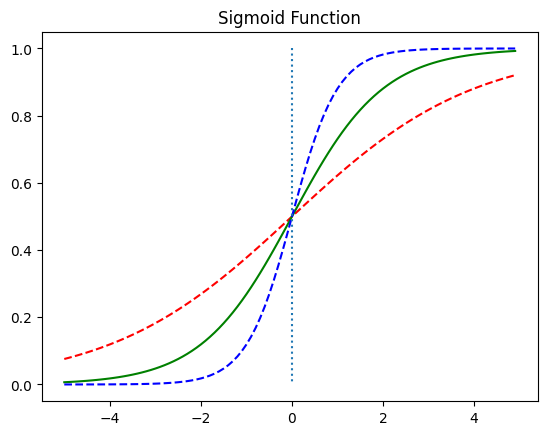

In [ ]:
x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(0.5*x)
y2 = sigmoid(x)
y3 = sigmoid(2*x)

plt.plot(x, y1, 'r', linestyle='--') # W의 값이 0.5일때
plt.plot(x, y2, 'g') # W의 값이 1일때
plt.plot(x, y3, 'b', linestyle='--') # W의 값이 2일때
plt.plot([0,0],[1.0,0.0], ':') # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.show()

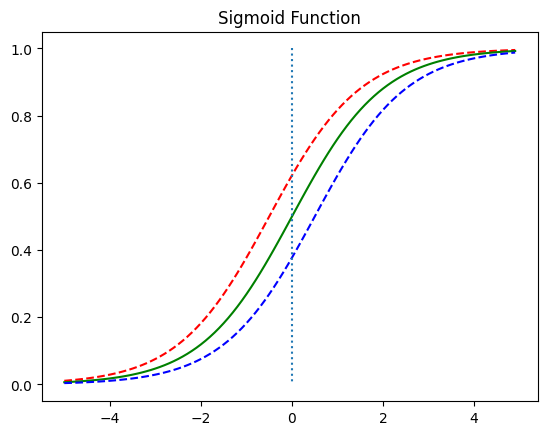

In [ ]:
x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(x+0.5)
y2 = sigmoid(x)
y3 = sigmoid(x-0.5)

plt.plot(x, y1, 'r', linestyle='--') # x + 0.5
plt.plot(x, y2, 'g') # x + 1
plt.plot(x, y3, 'b', linestyle='--') # x - 0.5
plt.plot([0,0],[1.0,0.0], ':') # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.show()


# Cost function
- 평균 제곱 오차를 사용하면
  - 미분했을 때 심한 비블록 형태의 그래프가 나옴
  - 경사 하강법을 사용하면 전역 최적해가 아닌 지역 최적해에 머무를 수 있음
- 따라서 로그 함수를 사용
  - cost(H(x), y) = -[ylogH(x) + (1-y)log(1-H(x))]

# 파이토치로 로지스틱 회귀 구현

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

In [ ]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

In [ ]:
W = torch.zeros((2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [ ]:
hypothesis = 1 / (1 + torch.exp(-(x_train.matmul(W) + b)))

In [ ]:
print(hypothesis) # 예측값인 H(x) 출력

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<MulBackward0>)


In [ ]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)

In [ ]:
print(hypothesis)
print(y_train)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)
tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])


In [ ]:
losses = -(y_train * torch.log(hypothesis) +
           (1 - y_train) * torch.log(1 - hypothesis))
print(losses)

cost = losses.mean()
print(cost)

tensor([[0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931]], grad_fn=<NegBackward0>)
tensor(0.6931, grad_fn=<MeanBackward0>)


In [ ]:
# 파이토치의 로지스틱 회귀의 비용 함수 이용
F.binary_cross_entropy(hypothesis, y_train)

tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)

In [ ]:
# 모델 초기화
W = torch.zeros((2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # Cost 계산
    hypothesis = torch.sigmoid(x_train.matmul(W) + b)
    cost = -(y_train * torch.log(hypothesis) +
             (1 - y_train) * torch.log(1 - hypothesis)).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))


Epoch    0/1000 Cost: 0.693147
Epoch  100/1000 Cost: 0.134722
Epoch  200/1000 Cost: 0.080643
Epoch  300/1000 Cost: 0.057900
Epoch  400/1000 Cost: 0.045300
Epoch  500/1000 Cost: 0.037261
Epoch  600/1000 Cost: 0.031673
Epoch  700/1000 Cost: 0.027556
Epoch  800/1000 Cost: 0.024394
Epoch  900/1000 Cost: 0.021888
Epoch 1000/1000 Cost: 0.019852


In [ ]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)
print(hypothesis)


tensor([[2.7648e-04],
        [3.1608e-02],
        [3.8977e-02],
        [9.5622e-01],
        [9.9823e-01],
        [9.9969e-01]], grad_fn=<SigmoidBackward0>)


In [ ]:
prediction = hypothesis >= torch.FloatTensor([0.5])
print(prediction)

tensor([[False],
        [False],
        [False],
        [ True],
        [ True],
        [ True]])


In [ ]:
print(W)
print(b)

tensor([[3.2530],
        [1.5179]], requires_grad=True)
tensor([-14.4819], requires_grad=True)


# **04-02. nn.Module과 클래스로 구현하는 로지스틱 회귀**

# nn.Linear와 nn.Sigmoid로 로지스틱 회귀 구현하기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

In [ ]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

In [ ]:
model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

In [ ]:
model(x_train)

tensor([[0.4020],
        [0.4147],
        [0.6556],
        [0.5948],
        [0.6788],
        [0.8061]], grad_fn=<SigmoidBackward0>)

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs+1):
  hypothesis = model(x_train)

  cost = F.binary_cross_entropy(hypothesis, y_train)

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch % 20 == 0:
        # 예측값이 0.5를 넘으면 True로 간주
        prediction = hypothesis >= torch.FloatTensor([0.5])
        # 실제값과 일치하는 경우만 True로 간주
        correct_prediction = prediction.float() == y_train
        # 정확도를 계산
        accuracy = correct_prediction.sum().item() / len(correct_prediction)
        # 각 에포크마다 정확도를 출력
        print('Epoch {:4d}/{} Cost: {:.6f} Accuracy {:2.2f}%'.format(
            epoch, nb_epochs, cost.item(), accuracy * 100,
        ))

Epoch    0/1000 Cost: 0.539713 Accuracy 83.33%
Epoch   20/1000 Cost: 0.441875 Accuracy 66.67%
Epoch   40/1000 Cost: 0.316358 Accuracy 83.33%
Epoch   60/1000 Cost: 0.220498 Accuracy 100.00%
Epoch   80/1000 Cost: 0.157299 Accuracy 100.00%
Epoch  100/1000 Cost: 0.134272 Accuracy 100.00%
Epoch  120/1000 Cost: 0.118297 Accuracy 100.00%
Epoch  140/1000 Cost: 0.105779 Accuracy 100.00%
Epoch  160/1000 Cost: 0.095704 Accuracy 100.00%
Epoch  180/1000 Cost: 0.087420 Accuracy 100.00%
Epoch  200/1000 Cost: 0.080486 Accuracy 100.00%
Epoch  220/1000 Cost: 0.074595 Accuracy 100.00%
Epoch  240/1000 Cost: 0.069526 Accuracy 100.00%
Epoch  260/1000 Cost: 0.065118 Accuracy 100.00%
Epoch  280/1000 Cost: 0.061247 Accuracy 100.00%
Epoch  300/1000 Cost: 0.057820 Accuracy 100.00%
Epoch  320/1000 Cost: 0.054764 Accuracy 100.00%
Epoch  340/1000 Cost: 0.052022 Accuracy 100.00%
Epoch  360/1000 Cost: 0.049546 Accuracy 100.00%
Epoch  380/1000 Cost: 0.047299 Accuracy 100.00%
Epoch  400/1000 Cost: 0.045251 Accuracy 100

In [ ]:
model(x_train)

tensor([[2.7616e-04],
        [3.1595e-02],
        [3.8959e-02],
        [9.5624e-01],
        [9.9823e-01],
        [9.9969e-01]], grad_fn=<SigmoidBackward0>)

In [ ]:
print(list(model.parameters()))

[Parameter containing:
tensor([[3.2534, 1.5181]], requires_grad=True), Parameter containing:
tensor([-14.4839], requires_grad=True)]


# 인공 신경망으로 표현되는 로지스틱 회귀
- 로지스틱 회귀는 인공 신경망으로 간주할 수 있음4
- 시그모이드 함수는 인공 신경망의 은닉층에서 거의 사용되지 않음

# 모델을 클래스로 구현
- 위의 코드와 아래의 코드는 똑같은 기능을 가짐

In [ ]:
model = nn.Sequential(
   nn.Linear(2, 1),
   nn.Sigmoid()
)

In [ ]:
class BinaryClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(2,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    return self.sigmoid(self.linear(x))

# 로지스틱 회귀 클래스로 구현

In [ ]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

In [ ]:
model = BinaryClassifier()

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs+1):
  hypothesis = model(x_train)

  cost = F.binary_cross_entropy(hypothesis, y_train)

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch % 20 == 0:
        # 예측값이 0.5를 넘으면 True로 간주
        prediction = hypothesis >= torch.FloatTensor([0.5])
        # 실제값과 일치하는 경우만 True로 간주
        correct_prediction = prediction.float() == y_train
        # 정확도를 계산
        accuracy = correct_prediction.sum().item() / len(correct_prediction)
        # 각 에포크마다 정확도를 출력
        print('Epoch {:4d}/{} Cost: {:.6f} Accuracy {:2.2f}%'.format(
            epoch, nb_epochs, cost.item(), accuracy * 100,
        ))

Epoch    0/1000 Cost: 0.778947 Accuracy 33.33%
Epoch   20/1000 Cost: 0.446548 Accuracy 66.67%
Epoch   40/1000 Cost: 0.318945 Accuracy 83.33%
Epoch   60/1000 Cost: 0.222594 Accuracy 100.00%
Epoch   80/1000 Cost: 0.158160 Accuracy 100.00%
Epoch  100/1000 Cost: 0.134716 Accuracy 100.00%
Epoch  120/1000 Cost: 0.118640 Accuracy 100.00%
Epoch  140/1000 Cost: 0.106051 Accuracy 100.00%
Epoch  160/1000 Cost: 0.095925 Accuracy 100.00%
Epoch  180/1000 Cost: 0.087604 Accuracy 100.00%
Epoch  200/1000 Cost: 0.080641 Accuracy 100.00%
Epoch  220/1000 Cost: 0.074728 Accuracy 100.00%
Epoch  240/1000 Cost: 0.069641 Accuracy 100.00%
Epoch  260/1000 Cost: 0.065218 Accuracy 100.00%
Epoch  280/1000 Cost: 0.061336 Accuracy 100.00%
Epoch  300/1000 Cost: 0.057899 Accuracy 100.00%
Epoch  320/1000 Cost: 0.054835 Accuracy 100.00%
Epoch  340/1000 Cost: 0.052085 Accuracy 100.00%
Epoch  360/1000 Cost: 0.049603 Accuracy 100.00%
Epoch  380/1000 Cost: 0.047352 Accuracy 100.00%
Epoch  400/1000 Cost: 0.045299 Accuracy 100